<a href="https://colab.research.google.com/github/YASHYOGESHAHIRE/04-zomato-data-analysis/blob/main/zomato_dataset_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('dark_background')

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("himanshupoddar/zomato-bangalore-restaurants")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'zomato-bangalore-restaurants' dataset.
Path to dataset files: /kaggle/input/zomato-bangalore-restaurants


In [ ]:
df = pd.read_csv('/kaggle/input/zomato-bangalore-restaurants/zomato.csv')

In [ ]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [ ]:
df.shape

(51717, 17)

In [ ]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [ ]:
columns_to_drop = ['url','address','phone','menu_item','dish_liked','reviews_list']
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]
df = df.drop(existing_columns_to_drop, axis=1)
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
0,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet,Banashankari
4,Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet,Banashankari


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         51717 non-null  object
 1   online_order                 51717 non-null  object
 2   book_table                   51717 non-null  object
 3   rate                         43942 non-null  object
 4   votes                        51717 non-null  int64 
 5   location                     51696 non-null  object
 6   rest_type                    51490 non-null  object
 7   cuisines                     51672 non-null  object
 8   approx_cost(for two people)  51371 non-null  object
 9   listed_in(type)              51717 non-null  object
 10  listed_in(city)              51717 non-null  object
dtypes: int64(1), object(10)
memory usage: 4.3+ MB


In [ ]:
df.drop_duplicates(inplace=True)
df.shape

(51609, 11)

In [ ]:
df['rate'].unique()


array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', nan, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '-', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5',
       '2.1 /5', '2.2 /5', '2.0 /5', '1.8 /5'], dtype=object)

Removing "NEW" , "-" , "/5" from rate column


In [ ]:
def handlerate(value):
  if(value=='NEW' or value=='-'):
    return np.nan
  else:
    value=str(value).split('/')
    print(value)
    value=value[0]
    return float(value)

df['rate'] = df['rate'].apply(handlerate)
df['rate'].head()

Streaming output truncated to the last 5000 lines.
['3.7 ', '5']
['3.3 ', '5']
['nan']
['nan']
['nan']
['nan']
['nan']
['nan']
['nan']
['nan']
['nan']
['nan']
['3.3 ', '5']
['3.8 ', '5']
['3.3 ', '5']
['nan']
['3.3 ', '5']
['3.2 ', '5']
['3.3 ', '5']
['3.4 ', '5']
['3.5 ', '5']
['2.6 ', '5']
['nan']
['nan']
['nan']
['nan']
['nan']
['nan']
['nan']
['nan']
['3.4 ', '5']
['nan']
['nan']
['3.3 ', '5']
['nan']
['3.3 ', '5']
['2.8 ', '5']
['nan']
['nan']
['4.2 ', '5']
['3.4 ', '5']
['3.2 ', '5']
['3.5 ', '5']
['3.3 ', '5']
['3.4 ', '5']
['3.4 ', '5']
['nan']
['3.9 ', '5']
['4.8 ', '5']
['3.8 ', '5']
['4.0 ', '5']
['3.9 ', '5']
['3.1 ', '5']
['4.0 ', '5']
['3.3 ', '5']
['3.6 ', '5']
['3.8 ', '5']
['3.5 ', '5']
['3.4 ', '5']
['3.5 ', '5']
['3.5 ', '5']
['3.4 ', '5']
['nan']
['2.9 ', '5']
['3.4 ', '5']
['nan']
['3.3 ', '5']
['nan']
['nan']
['nan']
['3.4 ', '5']
['3.3 ', '5']
['3.7 ', '5']
['3.3 ', '5']
['3.0 ', '5']
['nan']
['3.6 ', '5']
['nan']
['nan']
['3.6 ', '5']
['nan']
['nan']
['3.4 ', '5

,rate
0,4.1
1,4.1
2,3.8
3,3.7
4,3.8


In [ ]:
df.rate.isnull().sum()

np.int64(10019)

Filling Null Values in Rate Column with Mean

In [ ]:
df['rate'] = df['rate'].fillna(df['rate'].mean())
# right now df =, because, df. is depereciated in current version of pandas it creaes series object, dont make changes in original d

df.rate.isnull().sum()



np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51609 entries, 0 to 51716
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         51609 non-null  object 
 1   online_order                 51609 non-null  object 
 2   book_table                   51609 non-null  object 
 3   rate                         51609 non-null  float64
 4   votes                        51609 non-null  int64  
 5   location                     51588 non-null  object 
 6   rest_type                    51382 non-null  object 
 7   cuisines                     51564 non-null  object 
 8   approx_cost(for two people)  51265 non-null  object 
 9   listed_in(type)              51609 non-null  object 
 10  listed_in(city)              51609 non-null  object 
dtypes: float64(1), int64(1), object(9)
memory usage: 4.7+ MB


Dropping Null Values

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet,Banashankari
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet,Banashankari


In [ ]:
df.rename(columns={'approx_cost(for two people)':'cost2people','listed_in(type)':'type'},inplace=True)

In [ ]:
df['location'].unique()

array(['Banashankari', 'Basavanagudi', 'Mysore Road', 'Jayanagar',
       'Kumaraswamy Layout', 'Rajarajeshwari Nagar', 'Vijay Nagar',
       'Uttarahalli', 'JP Nagar', 'South Bangalore', 'City Market',
       'Nagarbhavi', 'Bannerghatta Road', 'BTM', 'Kanakapura Road',
       'Bommanahalli', 'CV Raman Nagar', 'Electronic City', 'HSR',
       'Marathahalli', 'Wilson Garden', 'Shanti Nagar',
       'Koramangala 5th Block', 'Koramangala 8th Block', 'Richmond Road',
       'Koramangala 7th Block', 'Jalahalli', 'Koramangala 4th Block',
       'Bellandur', 'Sarjapur Road', 'Whitefield', 'East Bangalore',
       'Old Airport Road', 'Indiranagar', 'Koramangala 1st Block',
       'Frazer Town', 'RT Nagar', 'MG Road', 'Brigade Road',
       'Lavelle Road', 'Church Street', 'Ulsoor', 'Residency Road',
       'Shivajinagar', 'Infantry Road', 'St. Marks Road',
       'Cunningham Road', 'Race Course Road', 'Commercial Street',
       'Vasanth Nagar', 'HBR Layout', 'Domlur', 'Ejipura',
       'Jeeva

Listed in(city) and location, both are there, lets keep only one


In [ ]:
df = df.drop(['listed_in(city)'],axis=1)

In [ ]:
df['cost2people'].unique()

array(['800', '300', '600', '700', '550', '500', '450', '650', '400',
       '900', '200', '750', '150', '850', '100', '1,200', '350', '250',
       '950', '1,000', '1,500', '1,300', '199', '80', '1,100', '160',
       '1,600', '230', '130', '50', '190', '1,700', '1,400', '180',
       '1,350', '2,200', '2,000', '1,800', '1,900', '330', '2,500',
       '2,100', '3,000', '2,800', '3,400', '40', '1,250', '3,500',
       '4,000', '2,400', '2,600', '120', '1,450', '469', '70', '3,200',
       '60', '560', '240', '360', '6,000', '1,050', '2,300', '4,100',
       '5,000', '3,700', '1,650', '2,700', '4,500', '140'], dtype=object)

Remove , from cost 2 people

In [ ]:
def handlecomma(value):
  value = str(value)
  if ',' in value:
    value = value.replace(',','')
  return float(value)

df['cost2people'] = df['cost2people'].apply(handlecomma)
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,cost2people,type
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,Buffet
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,Buffet


Cleaning Rest Type Column

In [ ]:
rest_types = df['rest_type'].value_counts(ascending=False)
rest_types

,count
rest_type,
Quick Bites,19010
Casual Dining,10253
Cafe,3682
Delivery,2574
Dessert Parlor,2242
...,...
"Dessert Parlor, Kiosk",2
"Dessert Parlor, Food Court",2
"Food Court, Beverage Shop",2


Making Rest Types less than 1000 in frequency as others

In [ ]:
rest_types_lessthan1000 = rest_types[rest_types<1000]
rest_types_lessthan1000

,count
rest_type,
Beverage Shop,863
Bar,686
Food Court,616
Sweet Shop,468
"Bar, Casual Dining",411
...,...
"Dessert Parlor, Kiosk",2
"Dessert Parlor, Food Court",2
"Food Court, Beverage Shop",2


In [ ]:
def handle_rest_type(value):
  if(value in rest_types_lessthan1000):
    return 'others'
  else:
    return value

df['rest_type'] = df['rest_type'].apply(handle_rest_type)
df['rest_type'].value_counts()

,count
rest_type,
Quick Bites,19010
Casual Dining,10253
others,9003
Cafe,3682
Delivery,2574
Dessert Parlor,2242
"Takeaway, Delivery",2008
Bakery,1140
"Casual Dining, Bar",1130


Cleaning Location Column

In [ ]:
location = df['location'].value_counts(ascending=False)
location

,count
location,
BTM,5056
HSR,2494
Koramangala 5th Block,2479
JP Nagar,2218
Whitefield,2105
...,...
West Bangalore,6
Yelahanka,5
Jakkur,3


In [ ]:
location = df['location'].value_counts(ascending=False)
location_lessthan300 = location[location<300]


In [ ]:
def handle_location(value):
  if (value in location_lessthan300):
    return 'others'
  else:
    return value

df['location'] = df['location'].apply(handle_location)
df['location'].value_counts()

,count
location,
BTM,5056
others,4954
HSR,2494
Koramangala 5th Block,2479
JP Nagar,2218
Whitefield,2105
Indiranagar,2026
Jayanagar,1916
Marathahalli,1805


Cleaning Cuisines Column


In [ ]:
cuisines = df['cuisines'].value_counts(ascending=False)
cuisines

,count
cuisines,
North Indian,2852
"North Indian, Chinese",2351
South Indian,1820
Biryani,903
"Bakery, Desserts",898
...,...
"North Indian, Chinese, Mughlai, Rolls",1
"Cafe, Healthy Food, Fast Food, Beverages",1
"Fast Food, Hot dogs",1


In [ ]:
cuisines_lessthan100 = cuisines[cuisines<100]
cuisines_lessthan100


,count
cuisines,
"North Indian, Continental, Chinese",97
Juices,94
"Fast Food, North Indian",93
"Bengali, North Indian",93
"Beverages, Juices",90
...,...
"North Indian, Chinese, Mughlai, Rolls",1
"Cafe, Healthy Food, Fast Food, Beverages",1
"Fast Food, Hot dogs",1


In [ ]:
def handle_cuisines(value):
  if (value in cuisines_lessthan100):
    return 'others'
  else:
    return value

df['cuisines'] = df['cuisines'].apply(handle_cuisines)

In [ ]:
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,cost2people,type
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,others,800.0,Buffet
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,others,others,800.0,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,others,600.0,Buffet


In [ ]:
df['type'].value_counts()

,count
type,
Delivery,25579
Dine-out,17562
Desserts,3559
Cafes,1703
Drinks & nightlife,1084
Buffet,869
Pubs and bars,686


DATA IS CLEAN, NOW LETS MOVE FORWARD TO VISUALIZATION

Count Plot of Various Locations

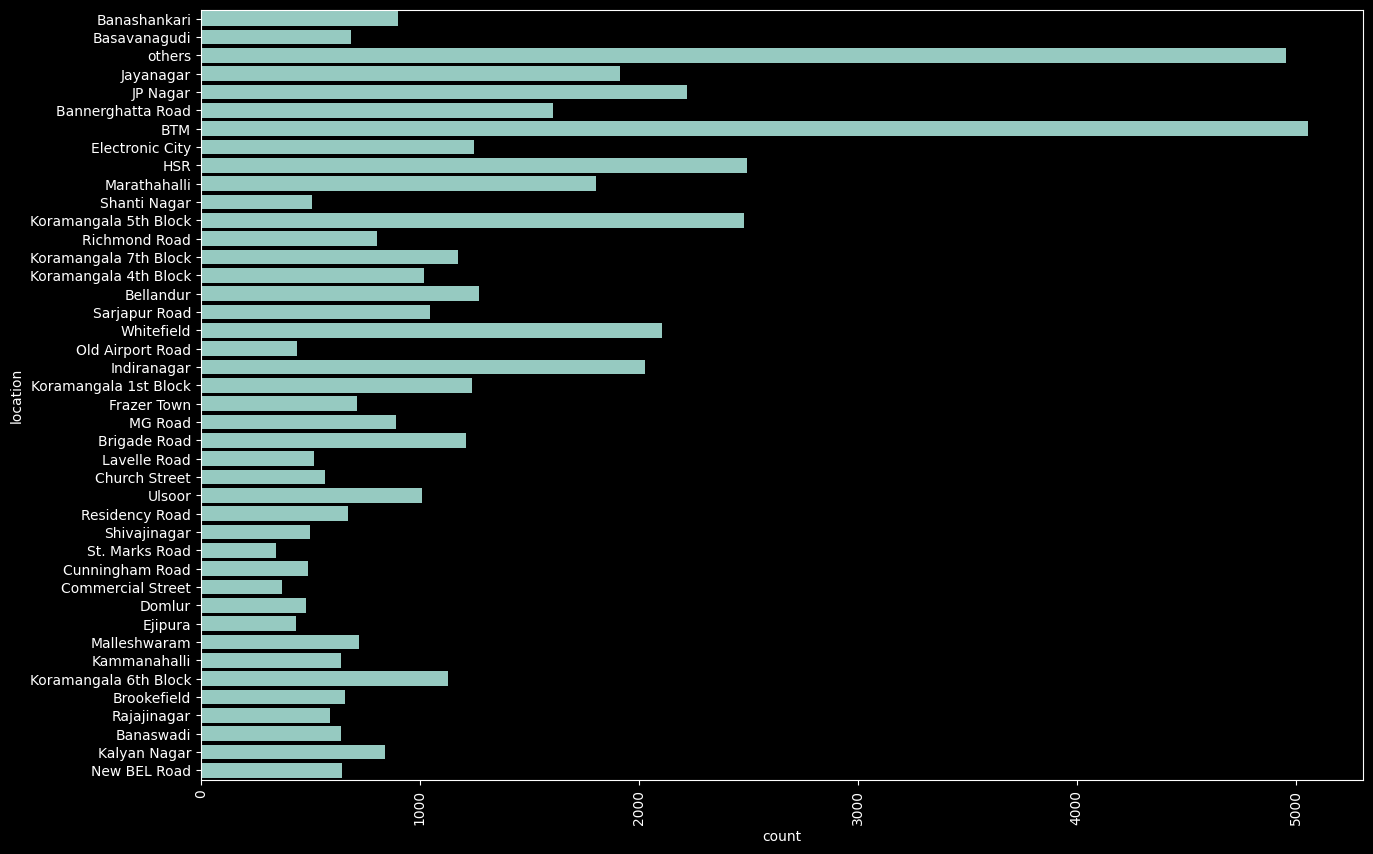

In [ ]:
plt.figure(figsize=(15,10))
sns.countplot(df['location'])
plt.xticks(rotation=90)
plt.show()

Visualizing Online Order

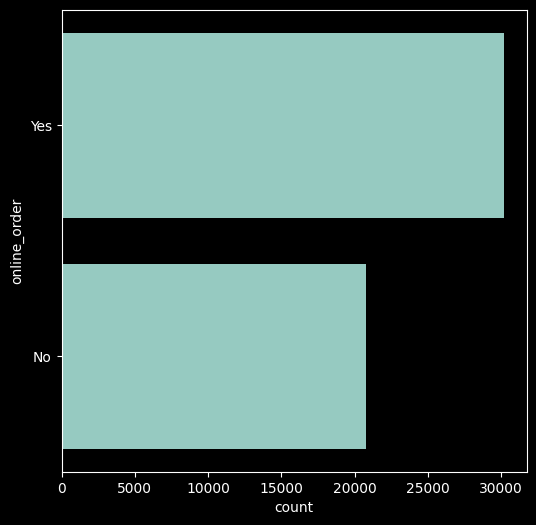

In [ ]:
plt.figure(figsize=(6,6))
sns.countplot(df['online_order'])
plt.show()

Visualizing Book Table

/tmp/ipykernel_694/2517773627.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df['book_table'],palette='rainbow')


<Axes: xlabel='count', ylabel='book_table'>

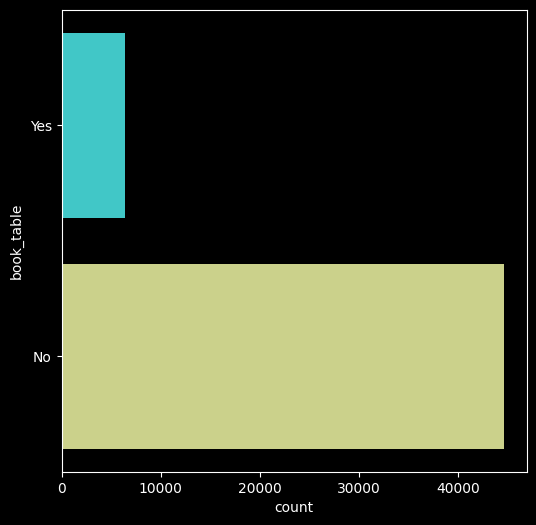

In [ ]:
plt.figure(figsize=(6,6))
sns.countplot(df['book_table'],palette='rainbow')

Visualizing Online Order vs Rate

<Axes: xlabel='online_order', ylabel='rate'>

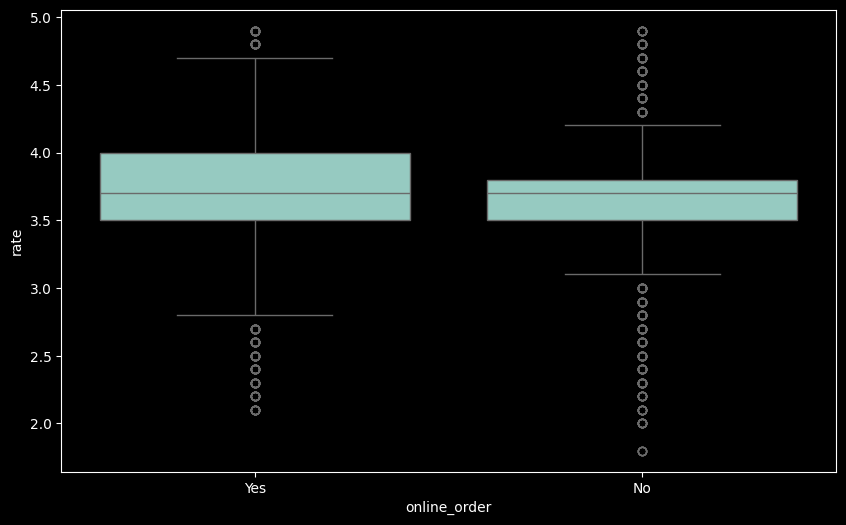

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='online_order',y='rate',data=df)

Visualizing book table vs rate

<Axes: xlabel='book_table', ylabel='rate'>

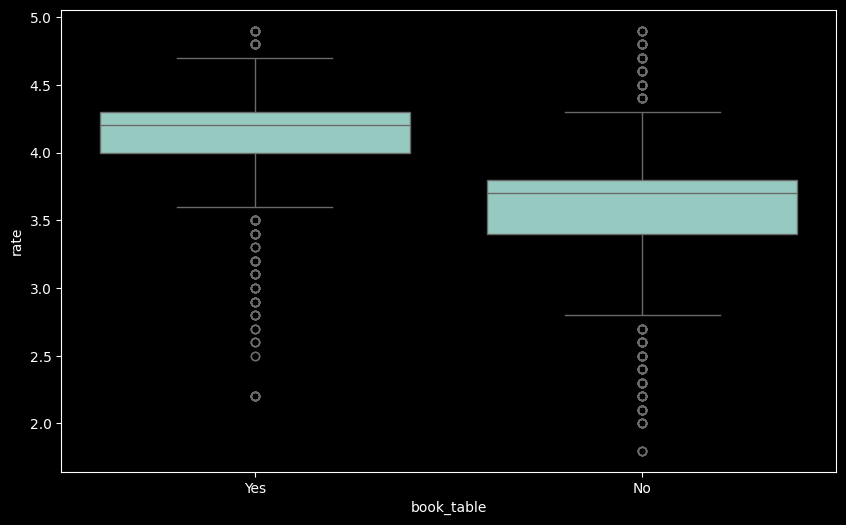

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='book_table',y='rate',data=df)

Visualizing Online Order Facility , Location Wise


In [ ]:
df1 = df.groupby(['location','online_order'])['name'].count()
df1.to_csv('location_online.csv')
df1 = pd.read_csv('location_online.csv')
df1.head()



,location,online_order,name
0,BTM,No,1763
1,BTM,Yes,3293
2,Banashankari,No,397
3,Banashankari,Yes,505
4,Banaswadi,No,302


<Axes: >

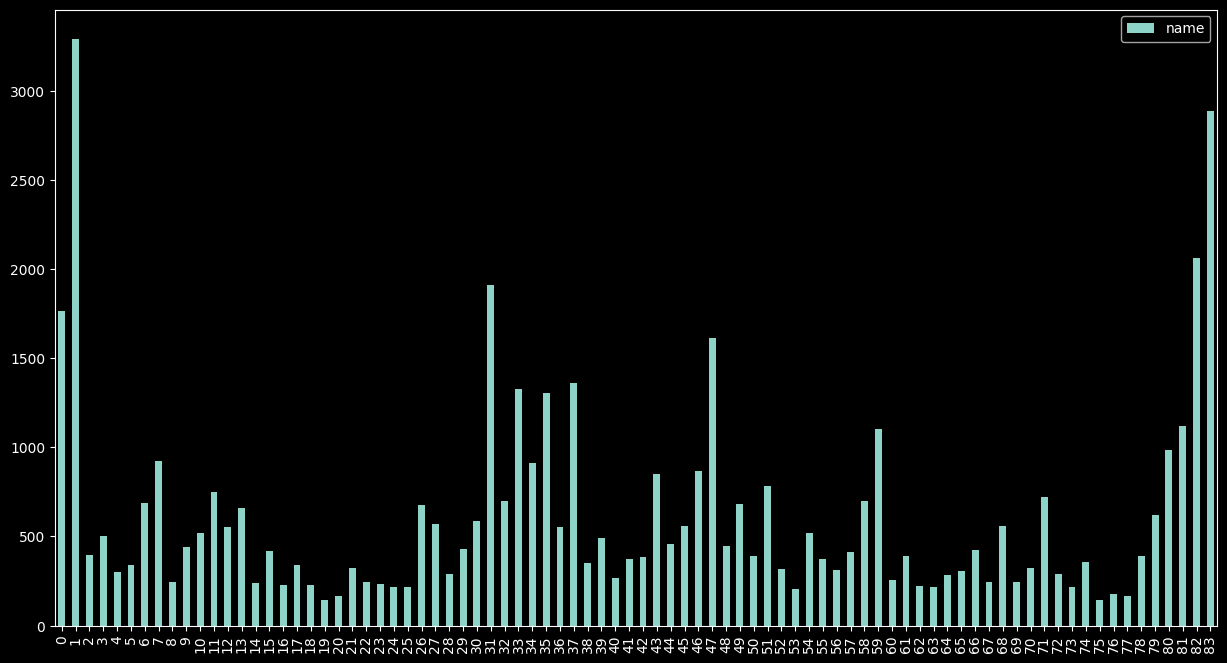

In [ ]:
df1.plot(kind = 'bar', figsize = (15,8))


Visualizing Book Table Facility, Location Wise

In [ ]:
df2 = df.groupby(['location','book_table'])['name'].count()
df2.to_csv('location_booktable.csv')
df2 = pd.read_csv('location_booktable.csv')
df2 = pd.pivot_table(df2, values=None, index=['location'], columns=['book_table'], fill_value=0, aggfunc=np.sum)
df2

/tmp/ipykernel_694/814380054.py:4: FutureWarning: The provided callable <function sum at 0x7ac574767d80> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df2 = pd.pivot_table(df2, values=None, index=['location'], columns=['book_table'], fill_value=0, aggfunc=np.sum)


name     
book_table               No  Yes
location                        
BTM                    4889  167
Banashankari            839   63
Banaswadi               632    8
Bannerghatta Road      1510   99
Basavanagudi            668   16
Bellandur              1170   98
Brigade Road           1034  176
Brookefield             582   74
Church Street           385  181
Commercial Street       370    0
Cunningham Road         315  175
Domlur                  427   55
Ejipura                 433    0
Electronic City        1148   98
Frazer Town             706    8
HSR                    2277  217
Indiranagar            1578  448
JP Nagar               1903  315
Jayanagar              1637  279
Kalyan Nagar            692  149
Kammanahalli            590   49
Koramangala 1st Block  1186   50
Koramangala 4th Block   695  322
Koramangala 5th Block  1787  692
Koramangala 6th Block  1015  112
Koramangala 7th Block  1012  162
Lavelle Road            290  228
MG Road                 546  347
Malleshwaram            632   89
Marathahalli           1642  163
New BEL Road            588   56
Old Airport Road        378   59
Rajajinagar             550   41
Residency Road          522  149
Richmond Road           687  116
Sarjapur Road           893  154
Shanti Nagar            451   57
Shivajinagar            475   23
St. Marks Road          219  124
Ulsoor                  834  177
Whitefield             1852  253
others                 4587  367

In [ ]:
df2

,location,book_table,name
0,BTM,No,4889
1,BTM,Yes,167
2,Banashankari,No,839
3,Banashankari,Yes,63
4,Banaswadi,No,632
...,...,...,...
77,Ulsoor,Yes,177
78,Whitefield,No,1852
79,Whitefield,Yes,253
80,others,No,4587


In [ ]:
df2.plot()